1. Stworzenie opisu projektu
2. Określenie problemu, cechy wejściowe
3. Wstępna analiza danych i ich wizualizacja
4. Sprawdzenie pomocniczych klas, czyli balans danych
5. Eksperyment 1 - analiza cech
6. Przygotowanie danych do modelu
7. Eksperyment 2 - regresja
8. Walidacja leave-one-out
9. Ocena modeli za pomocą metryk MAE RMSE, R^2
10. Analiza błędów 
11. Eksperyment 3 - klasteryzacja
12. Interpretacja klastrów
13. Porównanie wyników
14. Wnioski końcowe
15. Wizualizacja danych

___

### Opis projektu

Predykcja poziomu szczęścia krajów na podstawie wskaźników społeczno-ekonomicznych.

Wykorzystując zbiór danych World Happiness Report 2026, który zawiera informacje o krajach, ich wyniku szczęścia i dodatkowych czynnikach, zostanie stworzony model predykcji poziomu szczęścia krajów.

### Problem i cechy wejściowe

Celem jest przewidywanie wartości score, czyli liczbowego wyniku szczęścia kraju.

Typ problemu: uczenie nadzorowane i regresja wielowymiarowa.
Zmienna docelowa: `score`
Cechy wejściowe:

```
gdp_per_capita
social_support
healthy_life_expectancy
freedom
generosity
corruption
```

Dodatkowo będzie analizowana zmienna `region`.

### Wstępna analiza danych i wizualizacja

Stworzono wizualizacje danych:
- histogram wyniku szczęścia,
- top 10 najszczęśliwszych krajów,
- bottom 10 najszczęśliwszych krajów,
- zależność szczęścia od PKB,
- zależność szczęścia od wsparcia społecznego,
- średni score według regionu,
- macierz korelacji.

Sprawdzono również rozkład danych. Oprócz `generosity` zmienne są mocno powiązane ze `score`. Nie są zauważalne wartości odstające czy skrajne.

Analizę załączono na końcu tego dokumentu.

### Sprawdzenie pomocniczych klas

Zostanie sprawdzony balans danych. Utworzona zostanie zmienna pomocnicza `happiness_level.` Na podstawie wartości score kraje zostaną podzielone na grupy. 

Ze względu na to, że problemem jest regresja, niezbalansowanie tych klas nie jest kluczowym problemem dla modelu. Jednak jest to przydatna informacja.

### Eksperyment 1 - analiza danych

Celem jest sprawdzenie, które cechy są najbardziej powiązane z wynikiem szczęścia.

W eksperymencie wykonane zostanie:
- korelacja cech ze score,
- korelacja cech między sobą,
- ranking cech,
- analiza istotności cech.

Zostaną wykorzystane metody: `SelectKBest`, `f_regression` oraz `mutual_info_regression`.

### Przygotowanie danych do modelu

Zostaną przygotowane dane do uczenia maszynowego, czyli `X` jako cechy wejściowe oraz `y` jako zmienna docelowa score. Tutaj zostanie zdecydowane, czyli model będzie trenowany na wszystkich cechach czy tylko na tych najlepszych z eksperymentu nr 1.

Przygotowanie danych liczbowo:
- usunięcie nieużywanych kolumn,
- sprawdzenie braków danych,
- skalowanie cech.

### Eksperyment 2 - regresja

Porównanie kilka modeli regresyjnych, np. linear regression, ridge regression, lasso regression, random forest regressor, decision tree regressor.

### Walidacja Leave-one-out

Zostanie wykorzystana walidacja leave-one-out cross-validation, czyli model uczy się na 129 krajach i testuje na 1 kraju, a cały proces powtarza się 130 razy. Jest to dobra metoda na mały zbiór danych.

### Ocena modeli za pomocą MAE, RMSE i R^2

```
MAE — średni błąd bezwzględny
RMSE — średni błąd kwadratowy, mocniej karze duże błędy
R² — pokazuje, jaką część zmienności score wyjaśnia model
```

Porównane zostaną modele.

### Analiza błędów

Po wybraniu najlepszego modelu zostaną sprawdzone jego błędy. Tutaj odniesiemy się do pomocniczych klas, żeby sprawdzić, czy błąd modelu różni się między grupami.

### Eksperyment 3 - klasteryzacja 

Celem jest sprawdzenie, czy kraje można podzielić na grupy o podobnych cechach społeczno-ekonomicznych. Pomoże to znaleźć podobieństwa między krajami.

Wykorzystana metoda: K-Means.

### Interpretacja klastrów

Po klasteryzacji, sprawdzi się czym się różnią pojedyncze grupy.

### Porównanie wyników

Podsumowanie:
- które cechy miały największy związek ze score,
- który model regresyjny uzyskał najlepsze wyniki,
- czy leave-one-out był dobrym wyborem,
- czy klasteryzacja pokazała sensowne grupy krajów,
- czy wyniki regresji i klasteryzacji są ze sobą spójne.

### Wyniki końcowe

Czyli wnioski

# Wizualizacja analizy danych 
Analizowano zbiór danych World Happiness Report 2026, który zawiera informacje o krajach,
ich wyniku szczęścia i dodatkowych czynnikach 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('world_happiness_2026.csv')

data = df.to_numpy()
score = data[1:, 3]
score = score.astype(dtype=float)

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)


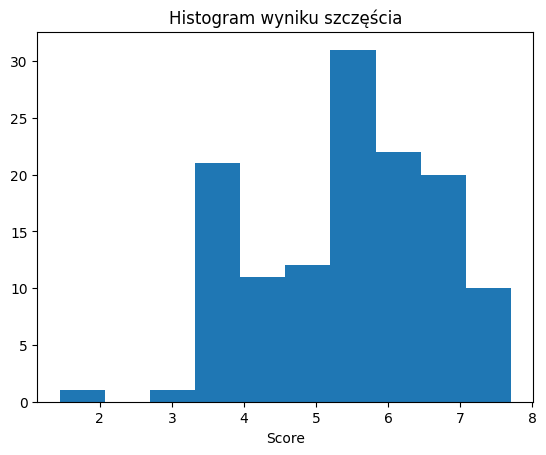

In [3]:
plt.hist(score)
plt.title("Histogram wyniku szczęścia")
plt.xlabel("Score")
plt.show()

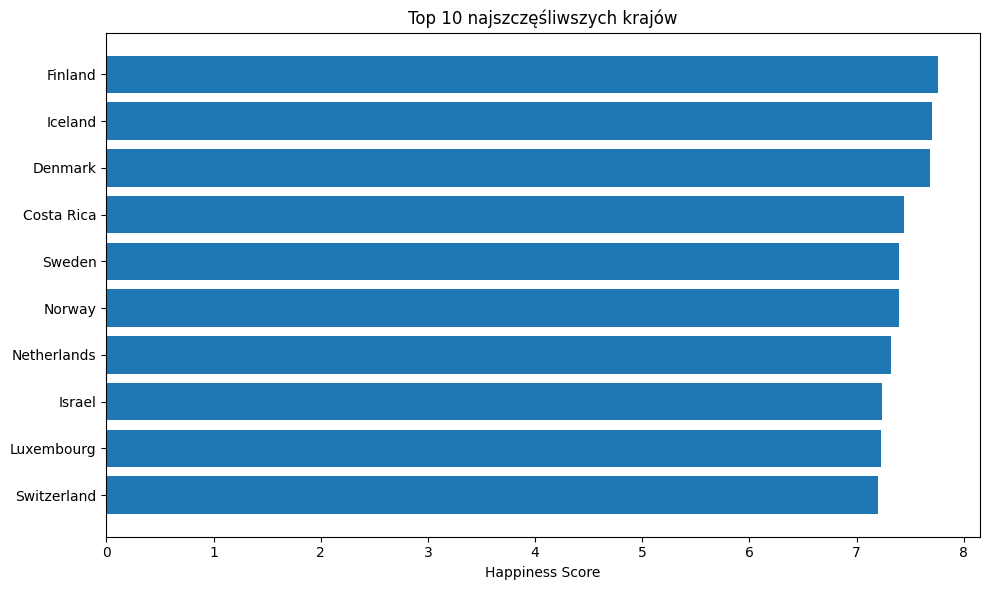

In [4]:
top10 = df.sort_values(by="score", ascending=False).head(10)
bottom10 = df.sort_values(by="score", ascending=True).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["country"], top10["score"])

plt.title("Top 10 najszczęśliwszych krajów")
plt.xlabel("Happiness Score")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

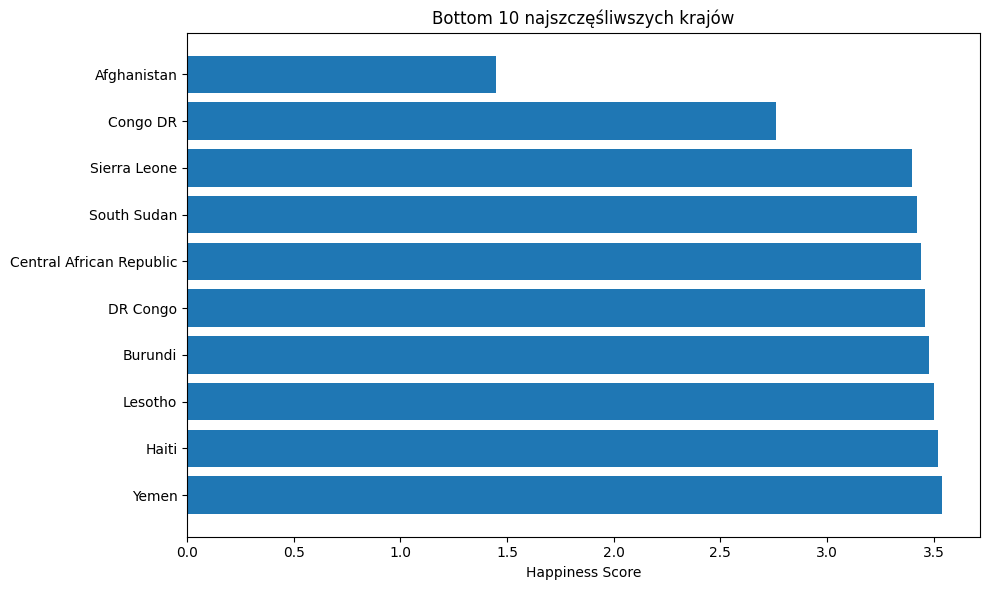

In [5]:
plt.figure(figsize=(10, 6))
plt.barh(bottom10["country"], bottom10["score"])

plt.title("Bottom 10 najszczęśliwszych krajów")
plt.xlabel("Happiness Score")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

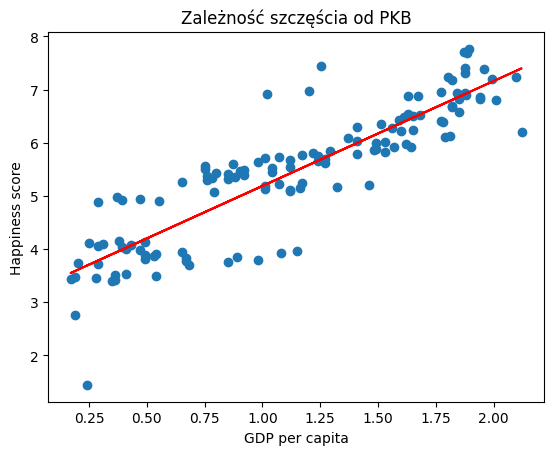

In [6]:
plt.scatter(df["gdp_per_capita"], df["score"])

m, b = np.polyfit(df["gdp_per_capita"], df["score"], 1)
plt.plot(df["gdp_per_capita"], m*df["gdp_per_capita"] + b, color="red")

plt.xlabel("GDP per capita")
plt.ylabel("Happiness score")
plt.title("Zależność szczęścia od PKB")
plt.show()

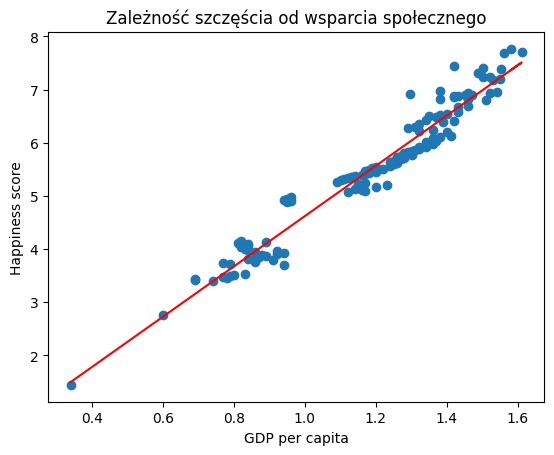

In [7]:
plt.scatter(df["social_support"], df["score"])

m, b = np.polyfit(df["social_support"], df["score"], 1)
plt.plot(df["social_support"], m*df["social_support"] + b, color="red")

plt.xlabel("GDP per capita")
plt.ylabel("Happiness score")
plt.title("Zależność szczęścia od wsparcia społecznego")
plt.show()

Wykres zależności szczęścia od wsparcia społecznego pokazuje zależność liniową.

region
Sub-Saharan Africa                    4.204256
South Asia                            4.816833
Middle East and North Africa          5.356929
Southeast Asia                        5.694333
Commonwealth of Independent States    5.757000
Latin America and Caribbean           5.874933
East Asia                             6.099200
Central and Eastern Europe            6.551273
North America and ANZ                 6.969000
Western Europe                        6.987167
Name: score, dtype: float64


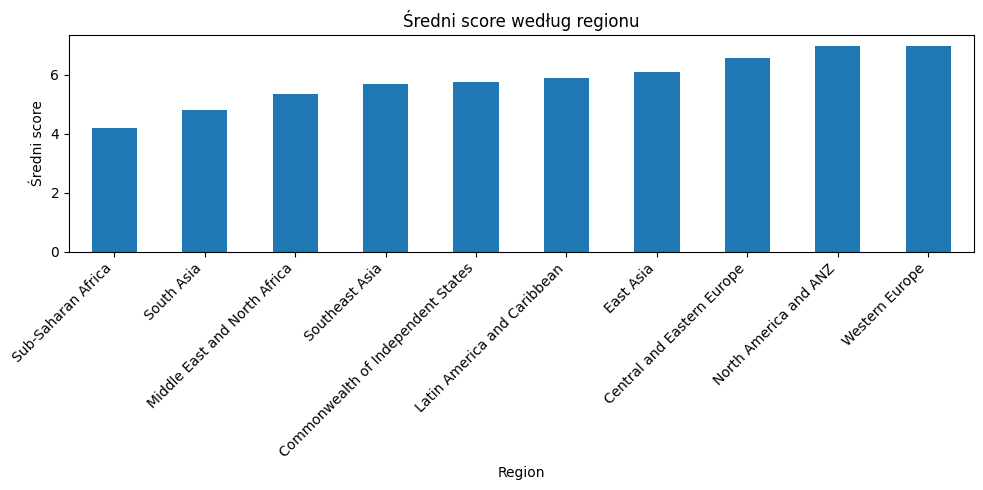

In [8]:
mean = df.groupby(["region"])["score"].mean().sort_values()

print(mean)

mean.plot(kind="bar", figsize=(10,5))

plt.title("Średni score według regionu")
plt.xlabel("Region")
plt.ylabel("Średni score")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

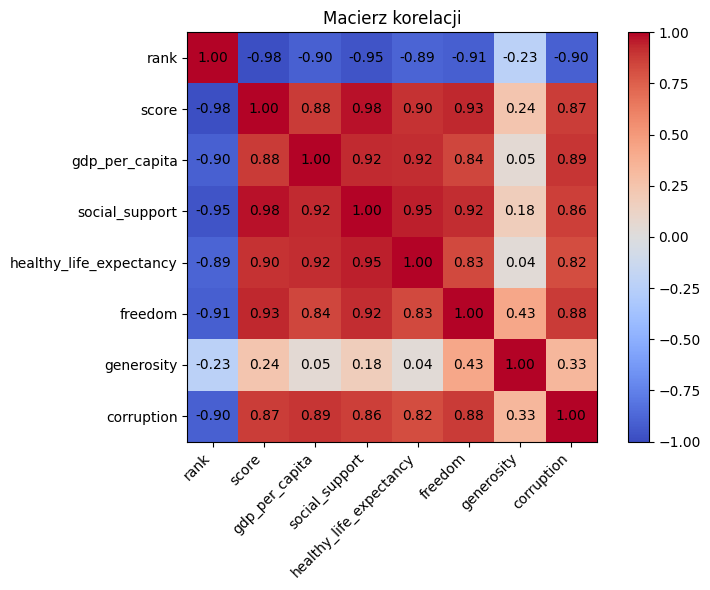

In [9]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8,6))

cax = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", color="black")

plt.colorbar(cax)
plt.title("Macierz korelacji")
plt.tight_layout()
plt.show()

Macierz korelacji pokazuje mocną zależność parametrów od wskaźnika "score".

In [10]:
df["happiness_level"] = pd.cut(df["score"], bins=3, labels=["Low", "Medium", "High"])
print(df["happiness_level"].value_counts())

happiness_level
High      61
Medium    59
Low       10
Name: count, dtype: int64


Dane są niezbalansowane, ale przedstawiają stan rzeczywisty. 
Będziemy wykorzystywać modele regresyjne, dlatego nie możemy na to wpłynąć.

## Eksperyment 1 - analiza cech
 Celem eksperymentu jest sprawdzenie, które cechy wejściowe są najmocniej powiązane ze zmienną docelową `score`. Analiza obejmuje korelacje liniowe, zależności między cechami oraz ranking cech wyznaczony metodami `SelectKBest`, `f_regression` i `mutual_info_regression`.


In [11]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, f_classif

features = [
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom",
    "generosity",
    "corruption",
]

X = df[features]
y = df["score"]


,correlation_with_score
social_support,0.976465
freedom,0.932961
healthy_life_expectancy,0.900567
gdp_per_capita,0.879284
corruption,0.874750
generosity,0.236826


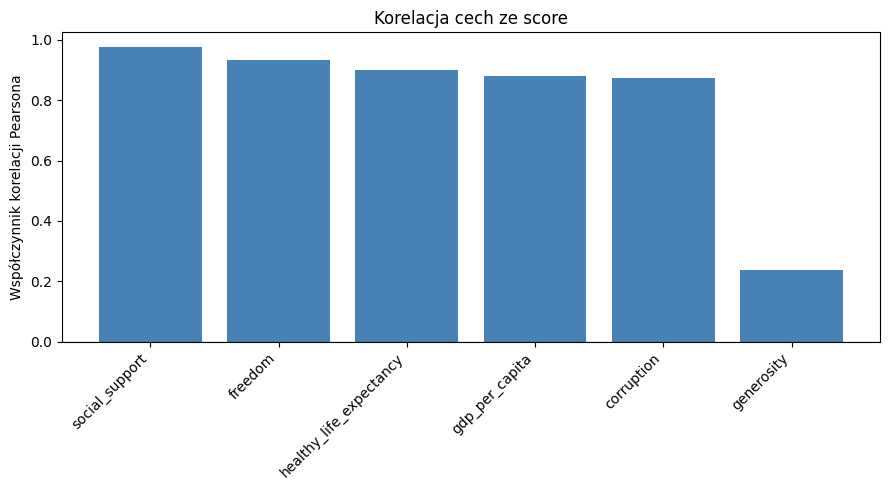

In [12]:
corr_with_score = X.corrwith(y)
corr_ranking = pd.DataFrame({"correlation_with_score": corr_with_score}).sort_values(by="correlation_with_score", ascending=False)

display(corr_ranking)

plt.figure(figsize=(9, 5))
plt.bar(corr_ranking.index, corr_ranking["correlation_with_score"], color="steelblue")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Korelacja cech ze score")
plt.ylabel("Współczynnik korelacji Pearsona")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


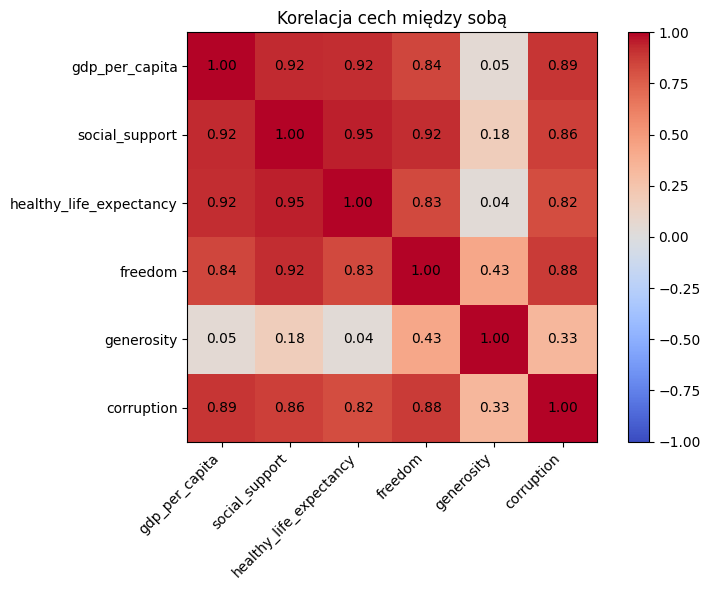

In [13]:
feature_corr = X.corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(feature_corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(features)))
ax.set_yticks(np.arange(len(features)))
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticklabels(features)

for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f"{feature_corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(cax)
plt.title("Korelacja cech między sobą")
plt.tight_layout()
plt.show()


In [14]:
selector = SelectKBest(score_func=f_regression, k=4)
selector.fit(X, y)

f_scores = selector.scores_
p_values = selector.pvalues_
mi_scores = mutual_info_regression(X, y, random_state=42)

feature_scores = pd.DataFrame({
    "feature": features,
    "correlation": corr_with_score.values,
    "f_regression_score": f_scores,
    "p_value": p_values,
    "mutual_info_score": mi_scores,
})

feature_scores["correlation_rank"] = feature_scores["correlation"].rank(ascending=False)
feature_scores["f_regression_rank"] = feature_scores["f_regression_score"].rank(ascending=False)
feature_scores["mutual_info_rank"] = feature_scores["mutual_info_score"].rank(ascending=False)
feature_scores["mean_rank"] = feature_scores[["correlation_rank", "f_regression_rank", "mutual_info_rank"]].mean(axis=1)

feature_scores = feature_scores.sort_values(by="mean_rank")
display(feature_scores.round(2))


,feature,correlation,f_regression_score,p_value,mutual_info_score,correlation_rank,f_regression_rank,mutual_info_rank,mean_rank
1,social_support,0.98,2623.78,0.00,1.86,1.0,1.0,1.0,1.00
3,freedom,0.93,859.78,0.00,1.11,2.0,2.0,3.0,2.33
2,healthy_life_expectancy,0.90,549.32,0.00,1.07,3.0,3.0,4.0,3.33
5,corruption,0.87,417.12,0.00,1.29,5.0,5.0,2.0,4.00
0,gdp_per_capita,0.88,436.23,0.00,0.96,4.0,4.0,5.0,4.33
4,generosity,0.24,7.61,0.01,0.19,6.0,6.0,6.0,6.00


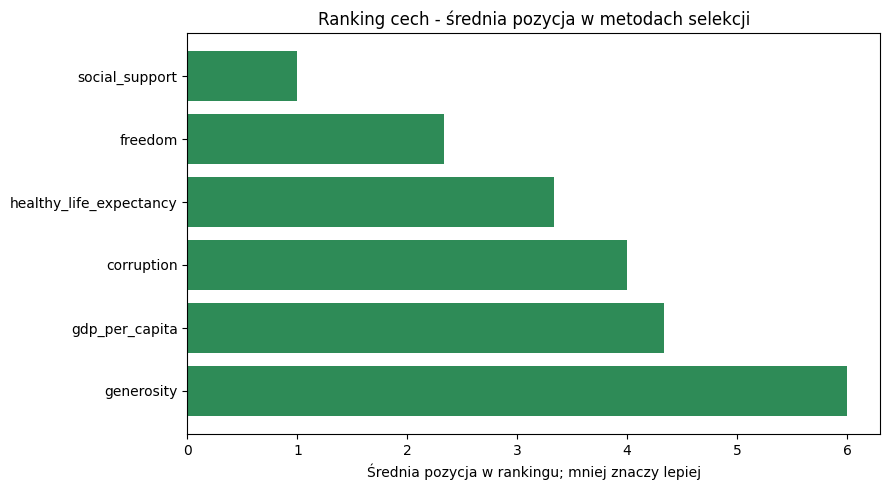

In [15]:
plt.figure(figsize=(9, 5))
plt.barh(feature_scores["feature"], feature_scores["mean_rank"], color="seagreen")
plt.gca().invert_yaxis()
plt.title("Ranking cech - średnia pozycja w metodach selekcji")
plt.xlabel("Średnia pozycja w rankingu; mniej znaczy lepiej")
plt.tight_layout()
plt.show()


### Dodatkowa analiza klasyfikacyjna - f_classif
 Ponieważ głównym problemem jest regresja, podstawowym testem pozostaje `f_regression`. Dodatkowo można jednak potraktować `score` jako trzy klasy: `Low`, `Medium` i `High`, a następnie sprawdzić, które cechy najlepiej rozróżniają te grupy metodą `f_classif`.


,country_count
happiness_level,
Low,10
Medium,59
High,61


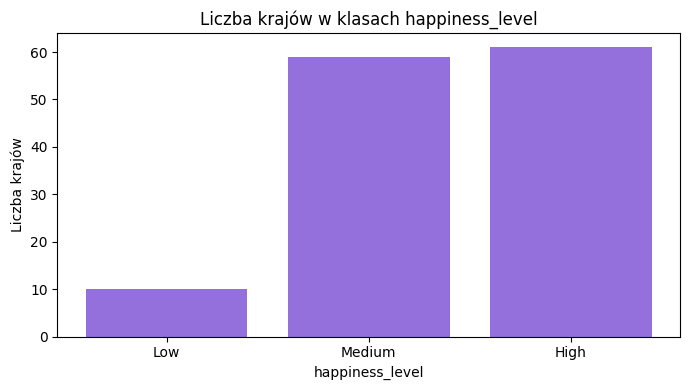

In [16]:
df["happiness_level"] = pd.cut(
    df["score"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

class_counts = df["happiness_level"].value_counts().sort_index()
display(class_counts.to_frame(name="country_count"))

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index.astype(str), class_counts.values, color="mediumpurple")
plt.title("Liczba krajów w klasach happiness_level")
plt.xlabel("happiness_level")
plt.ylabel("Liczba krajów")
plt.tight_layout()
plt.show()


In [17]:
selector_classif = SelectKBest(score_func=f_classif, k="all")
selector_classif.fit(X, df["happiness_level"])

classif_scores = pd.DataFrame({
    "feature": features,
    "f_classif_score": selector_classif.scores_,
    "p_value": selector_classif.pvalues_,
})

classif_scores["f_classif_rank"] = classif_scores["f_classif_score"].rank(ascending=False)
classif_scores = classif_scores.sort_values(by="f_classif_rank")

display(classif_scores.round(2))


,feature,f_classif_score,p_value,f_classif_rank
1,social_support,190.42,0.00,1.0
0,gdp_per_capita,180.76,0.00,2.0
2,healthy_life_expectancy,129.15,0.00,3.0
3,freedom,125.98,0.00,4.0
5,corruption,98.58,0.00,5.0
4,generosity,1.11,0.33,6.0


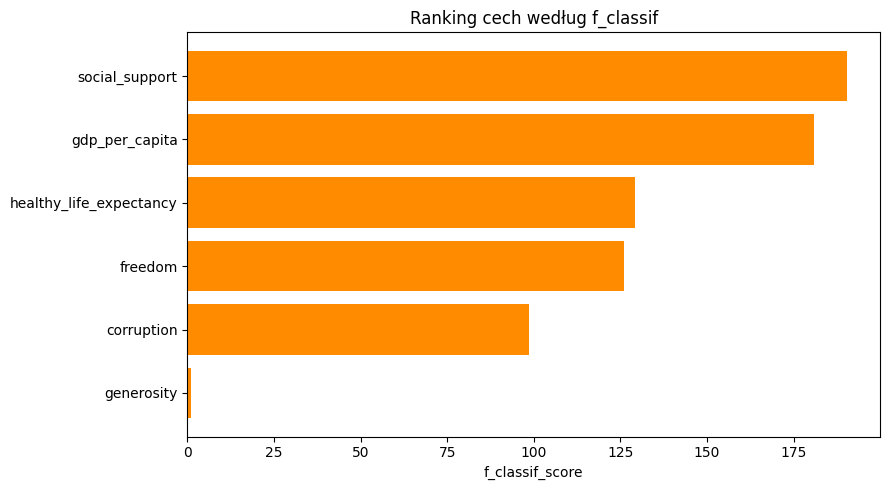

In [18]:
plt.figure(figsize=(9, 5))
plt.barh(classif_scores["feature"], classif_scores["f_classif_score"], color="darkorange")
plt.gca().invert_yaxis()
plt.title("Ranking cech według f_classif")
plt.xlabel("f_classif_score")
plt.tight_layout()
plt.show()


### Wnioski z eksperymentu 1

 Eksperyment 1 pokazał, że najważniejszą cechą dla przewidywania wyniku szczęścia jest `social_support`. Cecha ta uzyskała pierwsze miejsce we wszystkich zastosowanych metodach oceny. Wysoką zależność ze `score` wykazują także `freedom`, `healthy_life_expectancy`, `corruption` oraz `gdp_per_capita`. Wszystkie te cechy mają wysoką dodatnią korelację ze `score` i bardzo niskie wartości `p_value`, co wskazuje na istotną statystycznie zależność.

Najsłabszą cechą okazała się `generosity`. Pomimo że jej `p_value` wskazuje na istotność statystyczną, jej korelacja i wyniki rankingowe są wyraźnie niższe niż w przypadku pozostałych zmiennych. W dalszej części projektu można przygotować dwa warianty danych: pierwszy wykorzystujący wszystkie cechy oraz drugi bez `generosity`.

`f_classif` pokazuje, które cechy najlepiej odróżniają kraje z niskim, średnim i wysokim poziomem szczęścia. Wynik ten należy traktować jako analizę pomocniczą, ponieważ docelowo przewidywana jest wartość liczbowa `score`, a nie klasa `happiness_level`.


## Przygotowanie danych do modelu

Celem etapu jest przygotowanie zbioru danych do trenowania modeli regresyjnych. Zmienną docelowa jest `score`, a cechami są wskaźniki społeczno-ekonomiczne.

Na podstawie eksperymentu 1 przygotowane zostaną dwa warianty danych:
-  wariant ze wszystkimi cechami,
- wariant bez  cechy `genorosity`, która miała najsłabszy związek ze `score`.

In [19]:
features_all = [
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom",
    "generosity",
    "corruption"
]

features_without_generosity = [
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom",
    "corruption"
]

X_all = df[features_all]
X_without_generosity = df[features_without_generosity]
y = df["score"]

In [20]:
print("Braki danych w X_all:")
print(X_all.isnull().sum())

print("\nBraki danych w y:")
print(y.isnull().sum())

print("\nRozmiar X_all:", X_all.shape)
print("Rozmiar X_without_generosity:", X_without_generosity.shape)
print("Rozmiar y:", y.shape)


Braki danych w X_all:
gdp_per_capita             0
social_support             0
healthy_life_expectancy    0
freedom                    0
generosity                 0
corruption                 0
dtype: int64

Braki danych w y:
0

Rozmiar X_all: (130, 6)
Rozmiar X_without_generosity: (130, 5)
Rozmiar y: (130,)


## Eksperyment 2 - regresja

Celem eksperymentu jest porównanie kilku modeli regresyjnych przewidujących wartość `score`.
Porównane zostaną modele liniowe oraz modele drzewiaste. 

Testowane będą dwa warianty danych:
- wszystkie cechy,
- cechy bez `generosity`.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01, max_iter=10000),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

W eksperymencie użyto modeli regresyjnych:
- Linear Regression jako model bazowy,
- Ridge Regression i Lasso Regression jako modele liniowe z regularyzacją,
- Decision Tree Regressor jako prosty model nieliniowy,
- Random Forest Regressor jako model zespołowy oparty na wielu drzewach.

Modele liniowe korzystają ze skalowania cech, dlatego zastosowano `StandardScaler` w potoku `Pipeline`.

### Walidacja modeli metodą Leave-One-Out

W kolejnym kroku modele zostaną ocenione za pomocą walidacji krzyżowej Leave-One-Out. 
Ponieważ zbiór danych jest mały i zawiera 130 krajów, ta metoda pozwala wykorzystać prawie wszystkie dane do trenowania modelu.

W każdej iteracji model będzie trenowany na 129 krajach, a testowany na 1 kraju. 
Proces zostanie powtórzony 130 razy, tak aby każdy kraj został raz użyty jako przykład testowy.

In [22]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

loo = LeaveOneOut()

def evaluate_models(X, y, dataset_name):
    results = []

    for model_name, model in models.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        y_pred = cross_val_predict(pipeline, X, y, cv=loo)

        mae = mean_absolute_error(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        r2 = r2_score(y, y_pred)

        results.append({
            "dataset": dataset_name,
            "model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

    return pd.DataFrame(results)

### Ocena modeli za pomocą MAE, RMSE i R²

Do oceny modeli wykorzystano trzy metryki:
- MAE, czyli średni błąd bezwzględny,
- RMSE, czyli pierwiastek ze średniego błędu kwadratowego,
- R², czyli miarę dopasowania modelu do danych.

Niższe wartości MAE i RMSE oznaczają mniejszy błąd predykcji. 
Wyższa wartość R² oznacza lepsze dopasowanie modelu do danych.

In [23]:
results_all = evaluate_models(X_all, y, "all_features")
results_without_generosity = evaluate_models(
    X_without_generosity,
    y,
    "without_generosity"
)

results = pd.concat([results_all, results_without_generosity], ignore_index=True)
results = results.sort_values(by="RMSE").reset_index(drop=True)

display(results)

,dataset,model,MAE,RMSE,R2
0,all_features,Linear Regression,0.161602,0.214958,0.970467
1,all_features,Ridge Regression,0.160941,0.219737,0.969140
2,without_generosity,Linear Regression,0.169153,0.222729,0.968293
3,without_generosity,Ridge Regression,0.169926,0.227531,0.966912
4,without_generosity,Lasso Regression,0.178102,0.238953,0.963506
5,all_features,Lasso Regression,0.178252,0.239159,0.963443
6,all_features,Random Forest,0.188283,0.305147,0.940487
7,without_generosity,Random Forest,0.190941,0.306980,0.939770
8,all_features,Decision Tree,0.202854,0.321733,0.933841
9,without_generosity,Decision Tree,0.232285,0.363843,0.915390


### Analiza błędów

Po porównaniu modeli do dalszej analizy wybrano Linear Regression trenowany na wszystkich cechach. 
Model ten uzyskał najlepsze wyniki według metryk MAE, RMSE i R².

W tej części zostaną sprawdzone błędy predykcji najlepszego modelu. 
Analiza pozwoli zobaczyć, dla których krajów model pomylił się najbardziej oraz czy wielkość błędu różni się między pomocniczymi klasami `happiness_level`.

In [24]:
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

y_pred_best = cross_val_predict(best_model, X_all, y, cv=loo)

errors = df[["country", "region", "score", "happiness_level"]].copy()
errors["predicted_score"] = y_pred_best
errors["error"] = errors["score"] - errors["predicted_score"]
errors["absolute_error"] = errors["error"].abs()

errors_sorted = errors.sort_values(by="absolute_error", ascending=False)

display(errors_sorted.head(10))

,country,region,score,happiness_level,predicted_score,error,absolute_error
108,Rwanda,Sub-Saharan Africa,3.911,Medium,4.668263,-0.757263,0.757263
15,Kosovo,Central and Eastern Europe,6.910,High,6.314099,0.595901,0.595901
36,Hungary,Central and Eastern Europe,6.281,High,5.696822,0.584178,0.584178
3,Costa Rica,Latin America and Caribbean,7.439,High,6.954785,0.484215,0.484215
129,Afghanistan,South Asia,1.446,Low,0.974484,0.471516,0.471516
122,Lesotho,Sub-Saharan Africa,3.501,Low,3.958775,-0.457775,0.457775
85,Mauritius,Sub-Saharan Africa,5.171,Medium,5.612614,-0.441614,0.441614
65,Tajikistan,Commonwealth of Independent States,5.571,Medium,5.992272,-0.421272,0.421272
6,Netherlands,Western Europe,7.319,High,6.918286,0.400714,0.400714
126,South Sudan,Sub-Saharan Africa,3.421,Low,3.027928,0.393072,0.393072


Największy błąd model uzyskał dla Rwandy. Rzeczywisty wynik `score` wynosił 3.911, natomiast model przewidział 4.668263. Oznacza to, że model zawyżył wynik o około 0.76 punktu.

Duże błędy pojawiły się również dla Kosowa, Węgier, Kostaryki oraz Afganistanu. W przypadku Kosowa, Węgier i Kostaryki model przewidział wynik niższy niż rzeczywisty, natomiast dla Rwandy, Lesotho, Mauritiusa i Tadżykistanu model zawyżył wynik.

Większość największych błędów dotyczy krajów z klas `High` oraz `Medium`, ale wśród nich pojawiają się także kraje z klasy `Low`, takie jak Afganistan, Lesotho i Sudan Południowy. 

Oznacza to, że błędy nie występują wyłącznie w jednej grupie poziomu szczęścia.

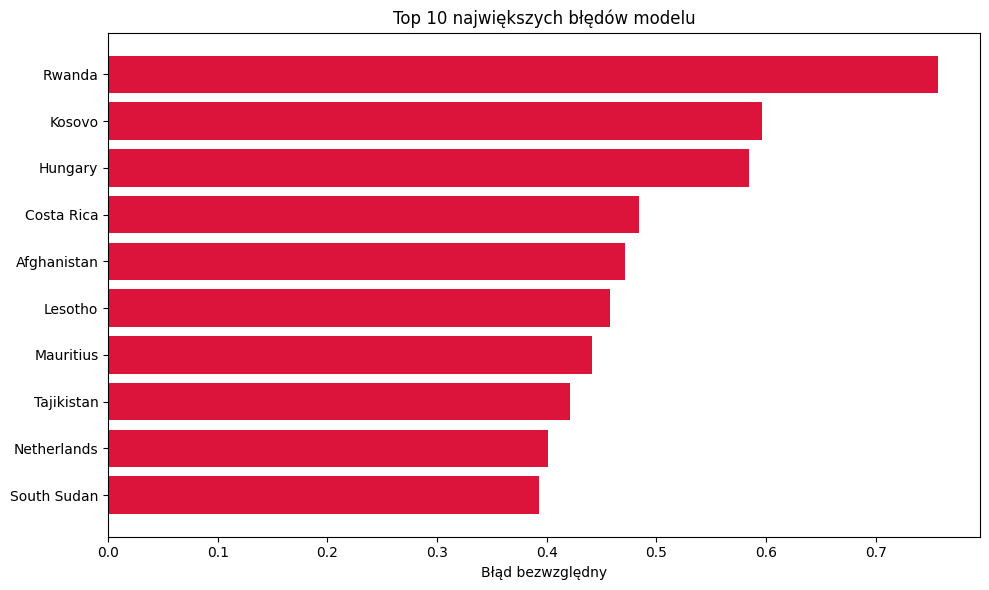

In [25]:
top_errors = errors_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_errors["country"], top_errors["absolute_error"], color="crimson")
plt.gca().invert_yaxis()
plt.title("Top 10 największych błędów modelu")
plt.xlabel("Błąd bezwzględny")
plt.tight_layout()
plt.show()

### Porównanie z najgorszym modelem

Postanowiono wykonać porównanie błędów najlepszego modelu z najgorszym modelem.

In [26]:
worst_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeRegressor(random_state=42))
])

y_pred_worst = cross_val_predict(worst_model, X_without_generosity, y, cv=loo)

worst_errors = df[["country", "region", "score", "happiness_level"]].copy()
worst_errors["predicted_score"] = y_pred_worst
worst_errors["error"] = worst_errors["score"] - worst_errors["predicted_score"]
worst_errors["absolute_error"] = worst_errors["error"].abs()

worst_errors_sorted = worst_errors.sort_values(by="absolute_error", ascending=False)

In [27]:
model_error_comparison = errors[["country", "absolute_error"]].rename(
    columns={"absolute_error": "linear_absolute_error"}
)

decision_tree_errors = worst_errors[["country", "absolute_error"]].rename(
    columns={"absolute_error": "decision_tree_absolute_error"}
)

model_error_comparison = model_error_comparison.merge(
    decision_tree_errors,
    on="country"
)

model_error_comparison["difference"] = (
    model_error_comparison["decision_tree_absolute_error"]
    - model_error_comparison["linear_absolute_error"]
)

model_error_comparison = model_error_comparison.sort_values(
    by="difference",
    ascending=False
).reset_index(drop=True)

mean_row = pd.DataFrame({
    "country": ["ŚREDNI BŁĄD"],
    "linear_absolute_error": [model_error_comparison["linear_absolute_error"].mean()],
    "decision_tree_absolute_error": [model_error_comparison["decision_tree_absolute_error"].mean()],
    "difference": [model_error_comparison["difference"].mean()]
})

model_error_comparison_with_mean = pd.concat(
    [model_error_comparison, mean_row],
    ignore_index=True
)

display(model_error_comparison_with_mean)

,country,linear_absolute_error,decision_tree_absolute_error,difference
0,Lebanon,0.213582,1.250000,1.036418
1,Afghanistan,0.471516,1.315000,0.843484
2,Tanzania,0.266466,1.080000,0.813534
3,Togo,0.140528,0.900000,0.759472
4,Malaysia,0.162955,0.920000,0.757045
5,Mexico,0.304529,1.061000,0.756471
6,Congo DR,0.010183,0.680000,0.669817
7,Kosovo,0.595901,1.139000,0.543099
8,Burkina Faso,0.260313,0.800000,0.539687
9,Slovakia,0.142324,0.570000,0.427676


Porównanie błędów najlepszego i najgorszego modelu pokazuje, że Linear Regression popełniał średnio mniejsze błędy niż Decision Tree. 
Średni błąd bezwzględny Linear Regression wyniósł 0.161602, natomiast dla Decision Tree wyniósł 0.232285.

Oznacza to, że Decision Tree mylił się średnio o około 0.07 punktu `score` bardziej niż Linear Regression. 
Dla części krajów Decision Tree uzyskał mniejszy błąd, jednak ogólnie Linear Regression był bardziej stabilnym modelem w całym zbiorze danych.

Wyniki te potwierdzają wcześniejszą ocenę modeli na podstawie MAE, RMSE i R².

### Test statystyczny

W celu sprawdzenia, czy różnica między najlepszym i najgorszym modelem jest istotna statystycznie, zastosowano test Wilcoxona dla prób zależnych. Porównano błędy bezwzględne obu modeli dla tych samych krajów.

Najpierw wykonano test Shapiro-Wilka, aby sprawdzić normalność rozkładu różnic błędów między modelami.

In [28]:
from scipy.stats import shapiro, wilcoxon

alpha = 0.05

differences = (
    model_error_comparison["decision_tree_absolute_error"]
    - model_error_comparison["linear_absolute_error"]
)

shapiro_stat, shapiro_p = shapiro(differences)

wilcoxon_stat, wilcoxon_p = wilcoxon(
    model_error_comparison["decision_tree_absolute_error"],
    model_error_comparison["linear_absolute_error"],
    alternative="greater"
)

statistical_test_results = pd.DataFrame({
    "test": ["Shapiro-Wilk", "Wilcoxon signed-rank"],
    "statistic": [shapiro_stat, wilcoxon_stat],
    "p_value": [shapiro_p, wilcoxon_p],
    "alpha": [alpha, alpha]
})

display(statistical_test_results)

if wilcoxon_p < alpha:
    print("Różnica błędów jest istotna statystycznie.")
    print("Decision Tree ma istotnie większe błędy bezwzględne niż Linear Regression.")
else:
    print("Nie ma podstaw do stwierdzenia istotnej statystycznie różnicy błędów.")

,test,statistic,p_value,alpha
0,Shapiro-Wilk,0.899381,7.171037e-08,0.05
1,Wilcoxon signed-rank,5221.000000,1.258204e-02,0.05


Różnica błędów jest istotna statystycznie.
Decision Tree ma istotnie większe błędy bezwzględne niż Linear Regression.


Test Shapiro-Wilka wykazał, że rozkład różnic błędów odbiega istotnie od rozkładu normalnego, `p < 0.001`. Z tego względu do porównania modeli zastosowano nieparametryczny test Wilcoxona dla prób zależnych. Wynik testu Wilcoxona był istotny statystycznie, `W = 5221`, `p = 0.0126 < 0.05`. Oznacza to, że model Decision Tree uzyskuje istotnie większe błędy bezwzględne niż Linear Regression.

## Eksperyment 3 - Klasteryzacja

Eksperyment przeprowadzono, aby znaleźć naturalne grupy krajów o podobnych cechach społeczno-ekonomicznych. Sprawdzono, czy dane same "mówią", że istnieją segmenty krajów o zbliżonym profilu.

Klasteryzacja pokaże, które kraje są podobne do siebie pod względem cech.

Użyto wszystkich cech (`features_all`), gdyż analizując poprzednie eksperymenty widać, że nie ma potrzeby wykluczać cechy `generosity`.

Najpierw zeskalowano dane, a następnie użyto metody łokcia, aby sprawdzić optymalną liczbę klastrów.

*SSE - Sum of Squared Errors*

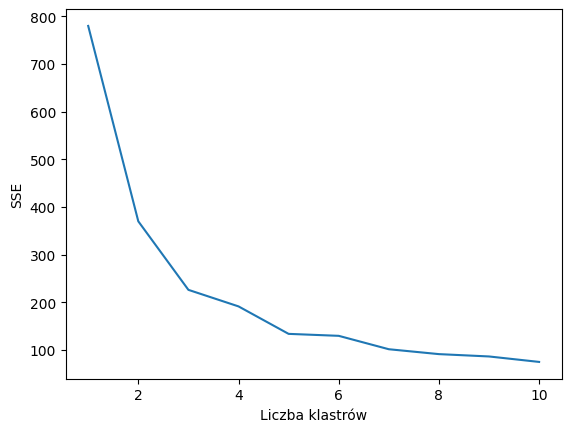

In [34]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_c = df[features_all]

# Skalowanie danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_c)


SSE = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    SSE.append(model.inertia_)

plt.plot(range(1, 11), SSE)
plt.xlabel("Liczba klastrów")
plt.ylabel("SSE")
plt.show()

Zastosowano liczbę klastrów równą 3.

Klasteryzację przeprowadzono przy użyciu `KMeans` i zwizualizowano redukując wymiary za pomocą `PCA`.

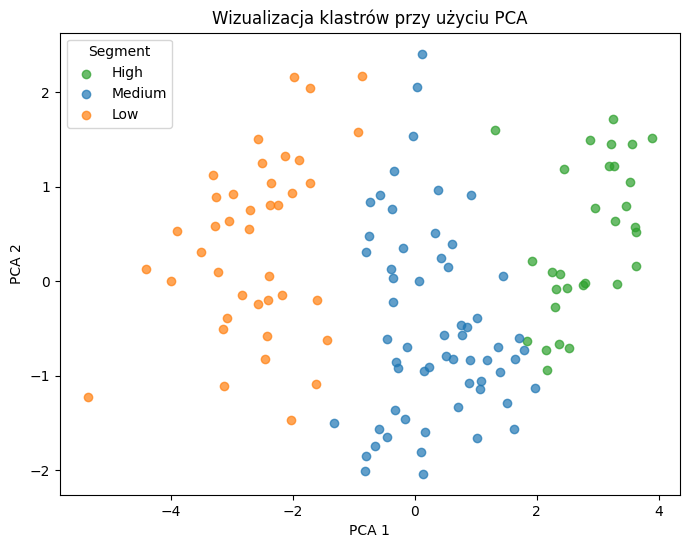

In [35]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# Klasteryzacja używając kmeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

# Redukcja wymiarowości
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
order = df.groupby("cluster")["score"].mean().sort_values().index

cluster_map = {
    order[0]: "Low",
    order[1]: "Medium",
    order[2]: "High"
}

df["cluster_label"] = df["cluster"].map(cluster_map)

plt.figure(figsize=(8,6))

colors = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

for cluster_id in df["cluster"].unique():
    mask = df["cluster"] == cluster_id
    
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[cluster_id],
        label=cluster_map[cluster_id],
        alpha=0.7
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Wizualizacja klastrów przy użyciu PCA")
plt.legend(title="Segment")
plt.show()

### Porównanie klastrów z `happiness_level` i metryka separacji
Poniższy kod pokazuje, jak grupy z klasteryzacji K-Means pokrywają się z pomocniczym podziałem `happiness_level`,
a także liczy współczynnik silhouette dla `k=3`, aby ocenić jakość podziału.


In [36]:
from sklearn.metrics import silhouette_score

if "happiness_level" not in df.columns:
    df["happiness_level"] = pd.cut(df["score"], bins=3, labels=["Low", "Medium", "High"])

ordered_labels = ["High", "Medium", "Low"]
df["cluster_label"] = pd.Categorical(df["cluster_label"], categories=ordered_labels, ordered=True)

print("Tabela kontyngencji klastra vs happiness_level:")
ct = pd.crosstab(df["cluster_label"], df["happiness_level"]).reindex(index=ordered_labels, columns=ordered_labels)
display(ct)

print("Rozmiary klastrów:")
display(df["cluster_label"].value_counts().reindex(ordered_labels))

sil = silhouette_score(X_scaled, kmeans.labels_)
print(f"Silhouette score dla k=3: {sil:.3f}")

cluster_means = df.groupby("cluster_label")[["score"] + features_all].mean().reindex(ordered_labels)
print("Średnie wartości cech w klastrach:")
display(cluster_means.round(3))


Tabela kontyngencji klastra vs happiness_level:


happiness_level,High,Medium,Low
cluster_label,,,
High,30,0,0
Medium,31,29,0
Low,0,30,10


Rozmiary klastrów:


cluster_label
High      30
Medium    60
Low       40
Name: count, dtype: int64

Silhouette score dla k=3: 0.419
Średnie wartości cech w klastrach:


,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
cluster_label,,,,,,,
High,6.949,1.828,1.471,0.924,0.628,0.207,0.382
Medium,5.742,1.222,1.255,0.804,0.498,0.144,0.161
Low,3.900,0.486,0.839,0.479,0.353,0.165,0.050


In [38]:
display(df[["country", "score", "cluster_label"]]
        .sort_values("score", ascending=False)
        .reset_index(drop=True))


,country,score,cluster_label
0,Finland,7.764,High
1,Iceland,7.701,High
2,Denmark,7.688,High
3,Costa Rica,7.439,High
4,Sweden,7.401,High
5,Norway,7.392,High
6,Netherlands,7.319,High
7,Israel,7.234,High
8,Luxembourg,7.228,High
9,Switzerland,7.201,High


Najwięcej krajów trafiło do klastra "Medium".

`Silhouette score` wyniósł 0,419, co oznacza, że klastry są umiarkowanie odseparowane i większość punktów znajduje się w poprawnym klastrze. 

Z tabeli powyżej widać, że wynik nie jest idealny, ale w większości dane zostały poprawnie skategoryzowane.